# 4. Evaluate: modes, spectrum, reconstruction

Load the trained checkpoint and inspect what NeuralDMD learned — this is where DMD's
interpretability pays off: the decomposition separates *what moves* from *what doesn't*, and
assigns each dynamic mode a frequency and decay rate you can read off directly.

In [1]:
import os
import numpy as np
import jax.numpy as jnp
import equinox as eqx
import jax
import matplotlib.pyplot as plt

from neural_dmd import NeuralDMD
from util_funcs import (load_hdf5, pixel_grid_coords, sort_modes_by_lambda,
                        plot_modes, plot_unit_circle, plot_frames,
                        make_gif, make_comparison_gif, write_mp4,
                        evaluate_chi2, calc_psnr)

obs_dir = "./data/EHT2017_cp/mring+hs_f0.04_resizedobs"
models_dir = "./models"
plots_dir = "./plots"
fov = np.pi
r, num_frequencies = 10, 2

key = jax.random.PRNGKey(0)
model = NeuralDMD(r, key=key, num_frequencies=num_frequencies)
model = eqx.tree_deserialise_leaves(
    os.path.join(models_dir, f"trained_model_r{r}_f{num_frequencies}.eqx"), model)

frames, times_hr = load_hdf5(obs_dir, "gt_video_resized.hdf5")
num_frames, height, width = frames.shape
frame_max, frame_min = frames.max(), frames.min()
t_span_hr = times_hr.max() - times_hr.min()
times = (times_hr - times_hr.min()) / t_span_hr

xy = pixel_grid_coords(height, width, fov, fov)
W0, W, Omega, b0, b = model(jnp.asarray(xy))
W_s, Omega_s, b_s = sort_modes_by_lambda(W, Omega, b)  # slowest-decaying first

## Spatial modes

The static mode `W0` should hold the m-ring; the leading dynamic modes carry the hot spot as
rotating patterns around the ring (real/imaginary parts are ~90° rotations of each other).

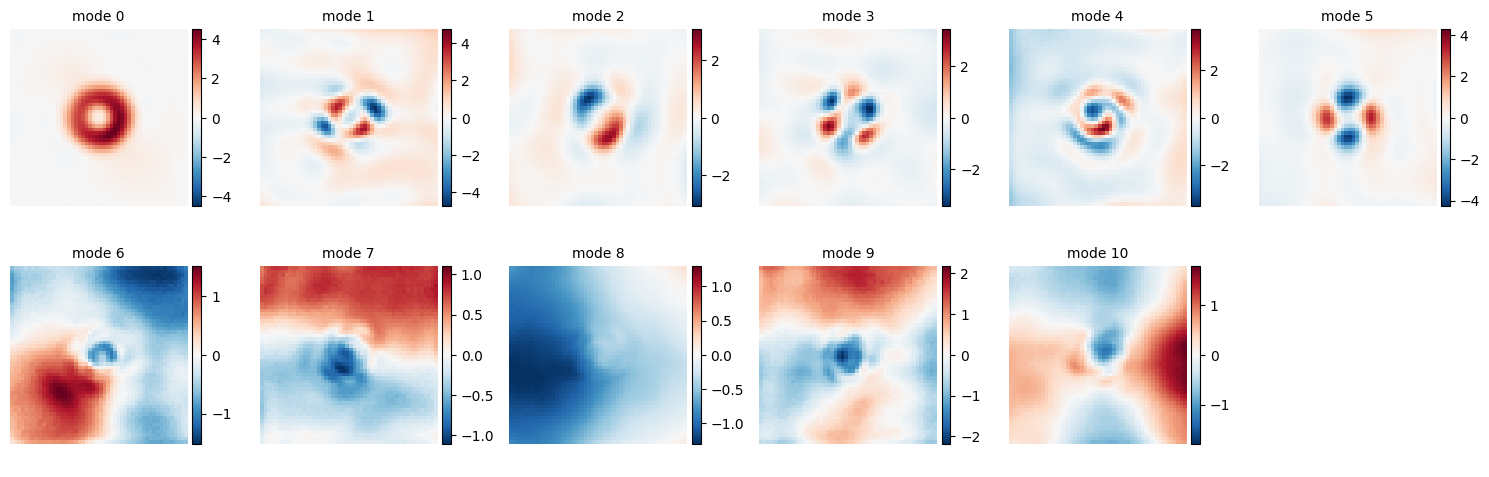

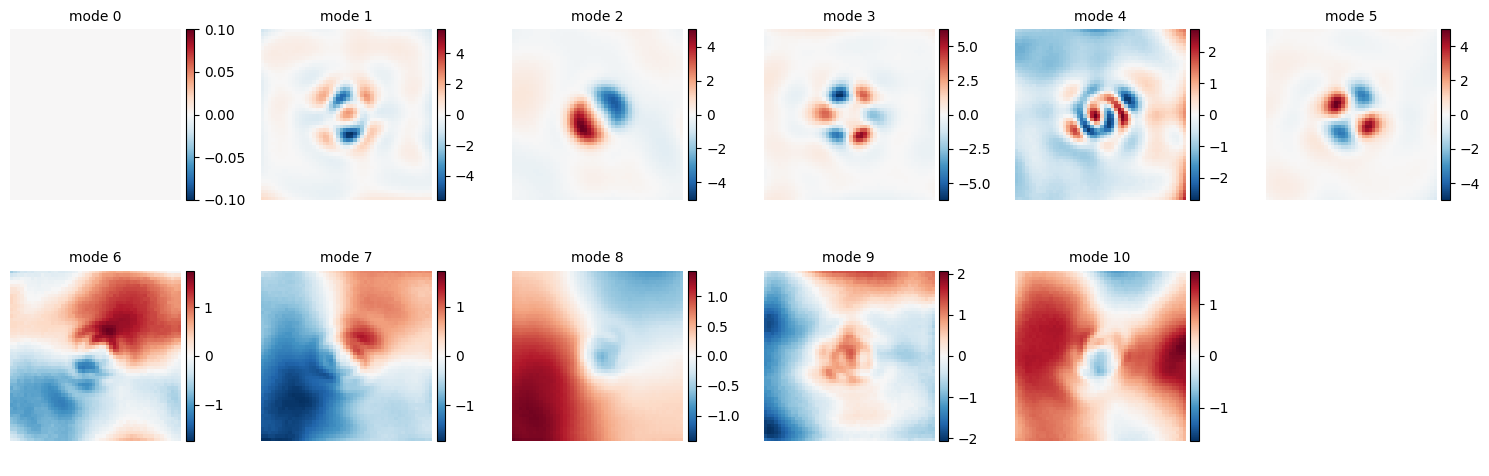

In [2]:
modes = np.concatenate([np.asarray(W0), np.asarray(W_s)], axis=1)
plot_modes(modes, height, width, title="mode", part="real");
plot_modes(modes, height, width, title="mode", part="imag");

## Temporal spectrum

Eigenvalues $\Lambda_k = e^{\Omega_k}$ sit on/inside the unit circle by construction
($\alpha_k \le 0$): on the circle = persistent oscillation, inside = decaying.

The frequency axis converts to a physical period via the model's time scaling
($\tau = t_{\rm scale}\, \tilde t$, with $\tilde t \in [0,1]$ spanning the observation):
$P_k = 2\pi\, T_{\rm span} / (\theta_k\, t_{\rm scale})$.
An 80-minute orbit over a 6-hour span corresponds to $\theta \approx 0.14$ — expect the
dominant mode there, with harmonics at multiples.

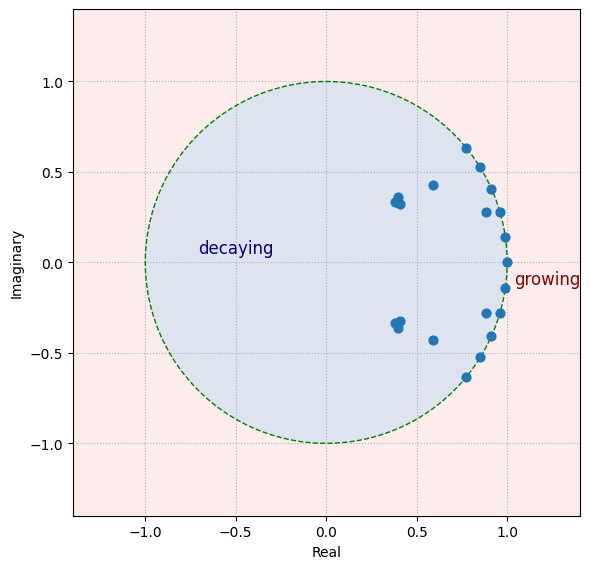

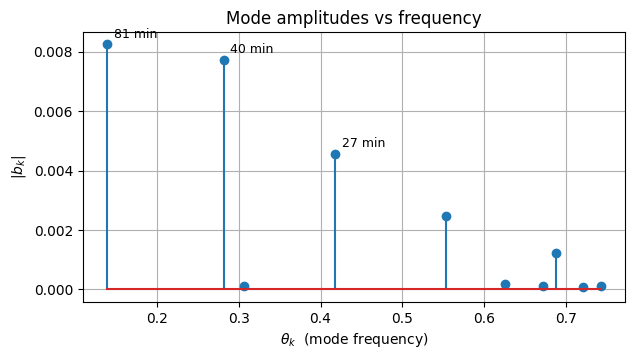

In [3]:
plot_unit_circle(np.asarray(Omega));

theta = np.asarray(Omega.imag)
period_min = 2 * np.pi * t_span_hr / (theta * model.t_scale + 1e-12) * 60.0

fig, ax = plt.subplots(figsize=(7, 3.5))
markerline, stemlines, _ = ax.stem(theta, np.abs(np.asarray(b)))
ax.set_xlabel(r"$\theta_k$  (mode frequency)"); ax.set_ylabel(r"$|b_k|$")
ax.set_title("Mode amplitudes vs frequency")
for k in np.argsort(np.abs(np.asarray(b)))[::-1][:3]:
    ax.annotate(f"{period_min[k]:.0f} min", (theta[k], abs(b[k])),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.grid(True); plt.show()

## Reconstruction

`model.reconstruct` returns the full movie plus its static/dynamic split — the split is what
lets you *watch the hot spot alone*.

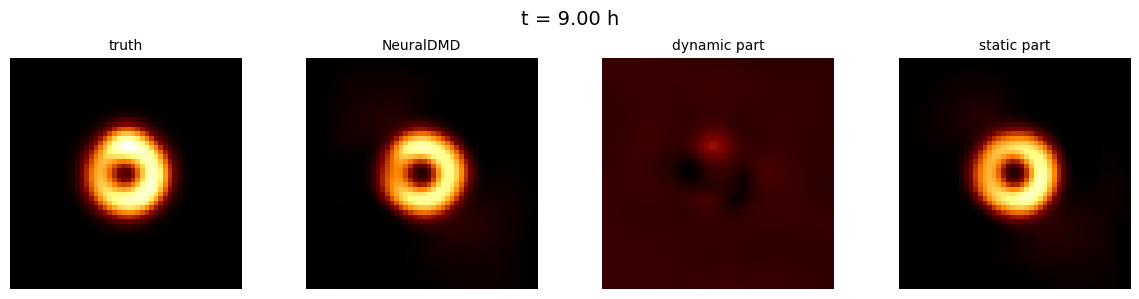

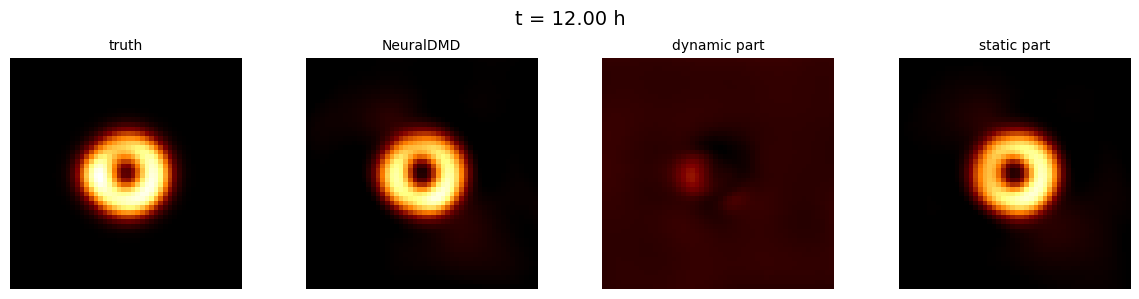

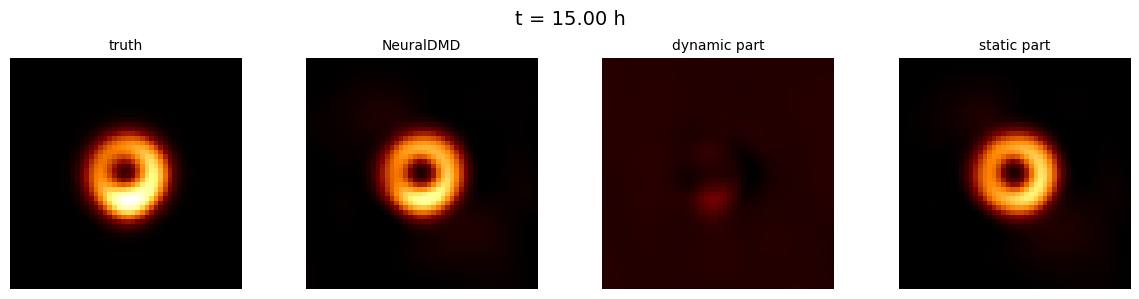

In [4]:
I_tot, I_stat, I_dyn = model.reconstruct(
    jnp.asarray(xy), jnp.asarray(times), frame_max=frame_max, frame_min=frame_min)

X_rec = np.asarray(I_tot).T.reshape(num_frames, height, width)
X_dyn = np.asarray(I_dyn).T.reshape(num_frames, height, width)
X_stat = np.asarray(I_stat).T.reshape(1, height, width)

for idx in [0, num_frames // 2, num_frames - 1]:
    plot_frames([frames[idx], X_rec[idx], X_dyn[idx] - X_dyn[idx].min(), X_stat[0]],
                titles=["truth", "NeuralDMD", "dynamic part", "static part"],
                suptitle=f"t = {times_hr[idx]:.2f} h")
plt.show()

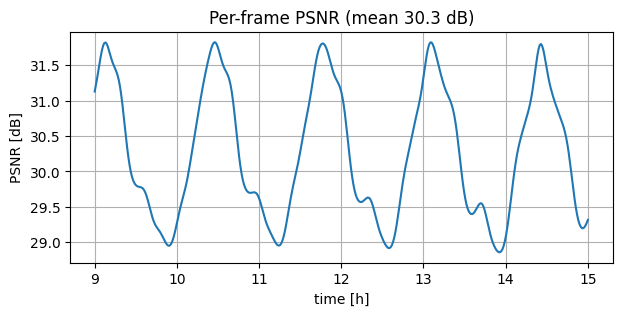

In [5]:
# image-space metric (never seen in training)
norm = lambda x: (x - frame_min) / (frame_max - frame_min)
psnr = [calc_psnr(norm(x), norm(f)) for x, f in zip(X_rec, frames)]
plt.figure(figsize=(7, 3))
plt.plot(times_hr, psnr)
plt.xlabel("time [h]"); plt.ylabel("PSNR [dB]"); plt.grid(True)
plt.title(f"Per-frame PSNR (mean {np.mean(psnr):.1f} dB)"); plt.show()

## Data-space goodness of fit

The definitive test: χ² of the reconstruction against **all** visibility data (reduced per
degree of freedom), compared with what the ground truth itself achieves (`diagnostics.json`,
≈ 0.6 here — below 1 because the error budget includes the 4% systematic term).

In [ ]:
import json
# This block doesn't work if the nubmer of observed frames are not aligned with number of frames in the video
chi2 = evaluate_chi2(np.asarray(I_tot), obs_dir)
ref = json.load(open(os.path.join(obs_dir, "diagnostics.json")))
print(f"reconstruction:  chi2_vis = {chi2['chi2_vis']:.2f}   chi2_amp = {chi2['chi2_amp']:.2f}   chi2_cp = {chi2['chi2_cp']:.2f}")
print(f"ground truth  :  chi2_vis = {ref['mean_vis_chi2']:.2f}   chi2_amp = {ref['mean_amp_chi2']:.2f}   chi2_cp = {ref['mean_cp_chi2']:.2f}")

## Forecasting

Because the temporal model is a spectrum, not a lookup table, evaluating beyond
$\tilde t = 1$ **extrapolates** the dynamics — here, half an orbit into the future.

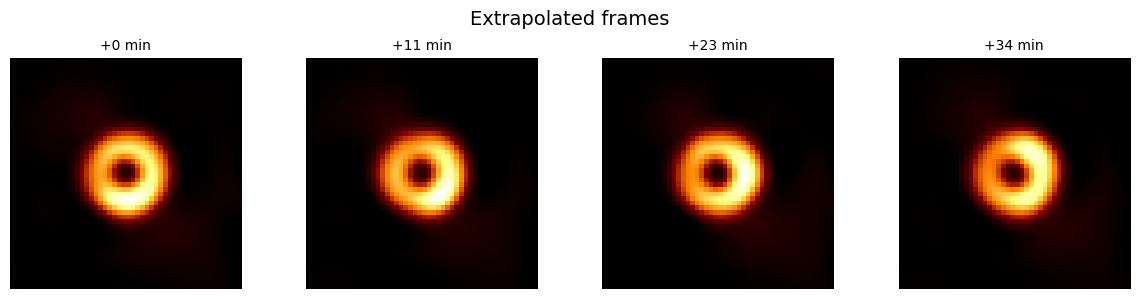

In [7]:
t_future = jnp.linspace(1.0, 1.0 + (40.0 / 60.0) / t_span_hr, 8)  # 40 min ahead
I_fut, _, _ = model.reconstruct(jnp.asarray(xy), t_future, frame_max=frame_max, frame_min=frame_min)
X_fut = np.asarray(I_fut).T.reshape(len(t_future), height, width)
plot_frames(list(X_fut[::2]),
            titles=[f"+{float(t - 1.0) * t_span_hr * 60:.0f} min" for t in t_future[::2]],
            suptitle="Extrapolated frames");
plt.show()

In [8]:
os.makedirs(plots_dir, exist_ok=True)
make_comparison_gif(frames, X_rec, os.path.join(plots_dir, "truth_vs_recon.gif"), fps=25)
make_gif(X_dyn - X_dyn.min(), os.path.join(plots_dir, "dynamic_part.gif"), fps=25)
# write_mp4(X_rec, os.path.join(plots_dir, "recon.mp4"), fps=25)  # needs imageio-ffmpeg

Saved ./plots/truth_vs_recon.gif
Saved ./plots/dynamic_part.gif
